# Random Policy Optuna Analysis
Study: `rand_policy_optuna_v1` — maximise `eval/success_rate` on `Ftr-Crossing-Direct-v0 / cur_mixed`

Search space (4 params):
- `linear_speed` — forward speed (m/s)
- `_amp` → `amp_min = amp_max` — flipper velocity amplitude
- `_freq` → `freq_min = freq_max` — flipper sinusoid frequency (log scale)
- `sync_flippers` — FL=FR and RL=RR vs 4 independent sines

In [10]:
STUDY_NAME = "rand_policy_optuna_v1"
DB_PATH    = "/home/robot/workspaces/robot_rodeo_gym_ws/optuna/rand_policy_optuna.db"
SR_COL     = "eval/success_rate"

In [11]:
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

storage = optuna.storages.RDBStorage(f"sqlite:///{DB_PATH}")
study   = optuna.load_study(study_name=STUDY_NAME, storage=storage)

all_trials = study.trials
trials     = [t for t in all_trials if t.state == optuna.trial.TrialState.COMPLETE]
print(f"Study : {STUDY_NAME}")
print(f"Trials: {len(all_trials)} total | {len(trials)} complete | "
      f"{sum(1 for t in all_trials if t.state == optuna.trial.TrialState.FAIL)} fail | "
      f"{sum(1 for t in all_trials if t.state == optuna.trial.TrialState.RUNNING)} running")

if not trials:
    raise RuntimeError("No completed trials found.")

records = []
for t in trials:
    sr = t.values[0] if t.values else t.user_attrs.get(SR_COL, float("nan"))
    row = {"trial": t.number, SR_COL: sr}
    row.update(t.params)
    records.append(row)

df = pd.DataFrame(records).sort_values("trial").reset_index(drop=True)

PARAM_NAMES = [c for c in df.columns if c not in {"trial", SR_COL}]
CONTINUOUS  = [p for p in PARAM_NAMES if p != "policy_opts.sync_flippers"]
CATEGORICAL = [p for p in PARAM_NAMES if p == "policy_opts.sync_flippers"]
LOG_PARAMS  = {"freq"}

def sname(p):
    return p.rsplit(".", 1)[-1] if "." in p else p

print(f"\nSuccess rate — min={df[SR_COL].min():.3f}  max={df[SR_COL].max():.3f}  "
      f"mean={df[SR_COL].mean():.3f}")
best = df.loc[df[SR_COL].idxmax()]
print(f"Best trial   : #{int(best['trial'])}  success_rate={best[SR_COL]:.4f}")
for p in PARAM_NAMES:
    print(f"  {sname(p):20s} = {best[p]}")
df.head()

Study : rand_policy_optuna_v1
Trials: 80 total | 80 complete | 0 fail | 0 running

Success rate — min=0.000  max=0.365  mean=0.199
Best trial   : #68  success_rate=0.3654
  linear_speed         = 0.7427421085667161
  amp                  = 0.9063770202592883
  freq                 = 0.053811900162905046
  sync_flippers        = True


,trial,eval/success_rate,policy_opts.linear_speed,amp,freq,policy_opts.sync_flippers
0,0,0.015790,0.152506,1.438244,0.285288,False
1,1,0.103248,0.989209,0.124967,0.257340,True
2,2,0.139727,0.660220,0.295795,0.002967,True
3,3,0.246296,0.955158,2.330869,0.105229,True
4,4,0.046081,0.624188,1.831928,0.040517,False


## Top trials

In [12]:
top_n = min(15, len(df))
top   = df.nlargest(top_n, SR_COL).copy()
top.columns = [sname(c) for c in top.columns]
with pd.option_context("display.max_columns", None, "display.width", 180,
                        "display.float_format", "{:.4f}".format):
    display(top)

,trial,eval/success_rate,linear_speed,amp,freq,sync_flippers
68,68,0.3654,0.7427,0.9064,0.0538,True
75,75,0.3605,0.8220,1.0001,0.0627,True
67,67,0.3558,0.7899,0.4741,0.0262,True
79,79,0.3548,0.9951,0.7887,0.0533,True
29,29,0.3541,0.6998,1.5752,0.0643,True
52,52,0.3495,0.7923,0.9294,0.0565,True
54,54,0.3470,0.8053,0.8762,0.0489,True
45,45,0.3412,0.7222,0.8164,0.0434,True
43,43,0.3388,0.6739,0.9362,0.0480,True
39,39,0.3345,0.6031,0.9617,0.0498,True


## Parameter vs success_rate scatter

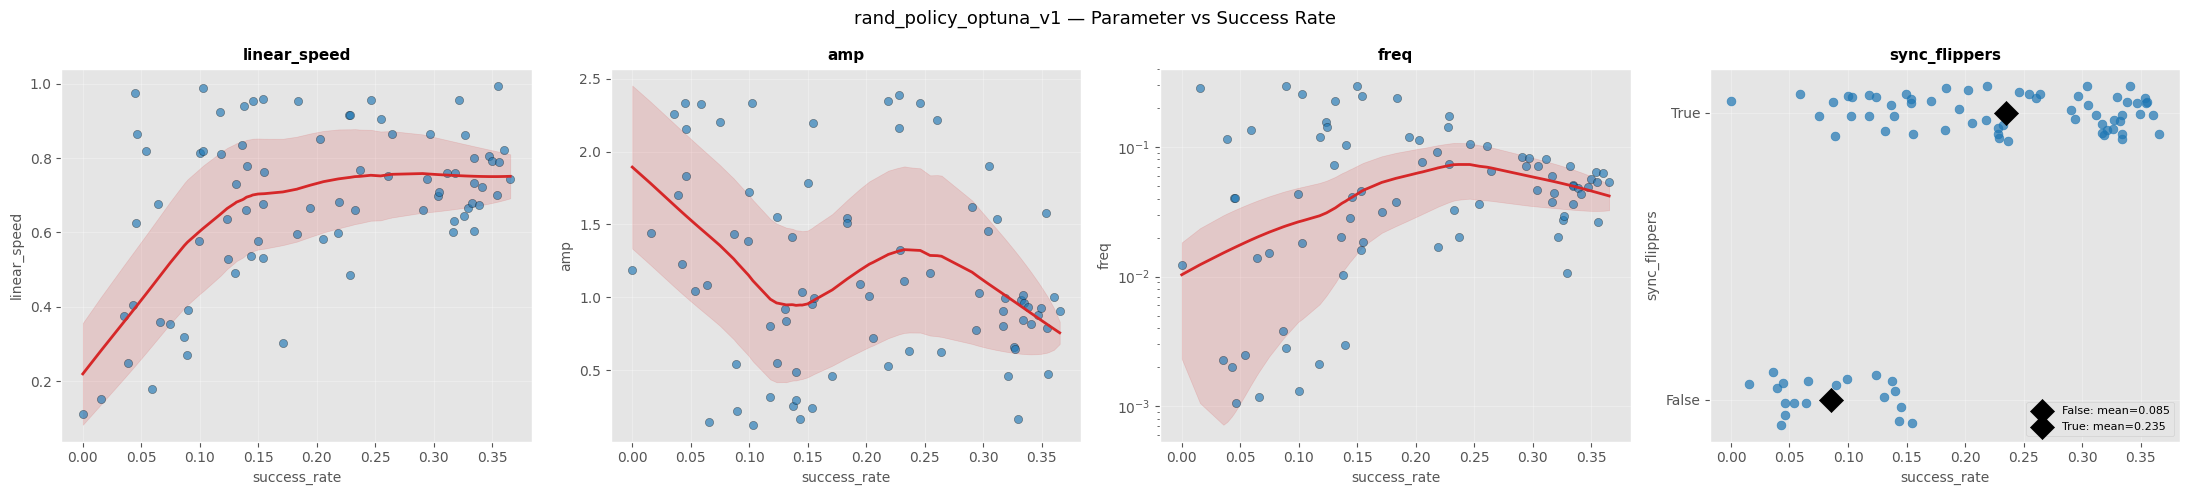

In [13]:
ncols = len(PARAM_NAMES)
fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 5))
axes = np.atleast_1d(axes)

for ax, param in zip(axes, PARAM_NAMES):
    x = df[SR_COL].values
    y = df[param].values

    if param in CATEGORICAL:
        categories = sorted(df[param].unique())
        for i, cat in enumerate(categories):
            vals   = df.loc[df[param] == cat, SR_COL].values
            jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(vals))
            ax.scatter(vals, np.full_like(vals, i) + jitter, s=40, alpha=0.7,
                       color="#1f77b4", zorder=3)
            ax.scatter(vals.mean(), i, s=150, marker="D", color="black", zorder=5,
                       label=f"{cat}: mean={vals.mean():.3f}")
        ax.set_yticks(range(len(categories)))
        ax.set_yticklabels([str(c) for c in categories])
        ax.legend(fontsize=8)
    else:
        order = np.argsort(x)
        xs, ys = x[order], y[order]
        ax.scatter(xs, ys, s=35, alpha=0.65, color="#1f77b4",
                   edgecolors="black", linewidths=0.3, zorder=3)
        if len(xs) >= 8:
            sm    = lowess(ys, xs, frac=0.5, return_sorted=True)
            resid = ys - np.interp(xs, sm[:, 0], sm[:, 1])
            std_s = np.sqrt(np.maximum(
                lowess(resid**2, xs, frac=0.5, return_sorted=True)[:, 1], 0))
            ax.plot(sm[:, 0], sm[:, 1], "-", linewidth=2, color="#d62728", zorder=5)
            ax.fill_between(sm[:, 0], sm[:, 1] - std_s, sm[:, 1] + std_s,
                            color="#d62728", alpha=0.15, zorder=2)
        if param in LOG_PARAMS:
            ax.set_yscale("log")

    ax.set_xlabel("success_rate", fontsize=10)
    ax.set_ylabel(sname(param), fontsize=10)
    ax.set_title(sname(param), fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

fig.suptitle(f"{STUDY_NAME} — Parameter vs Success Rate", fontsize=13)
fig.tight_layout()
plt.show()

## Convergence over time

/tmp/ipykernel_15732/1395613704.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.92, 1.0])


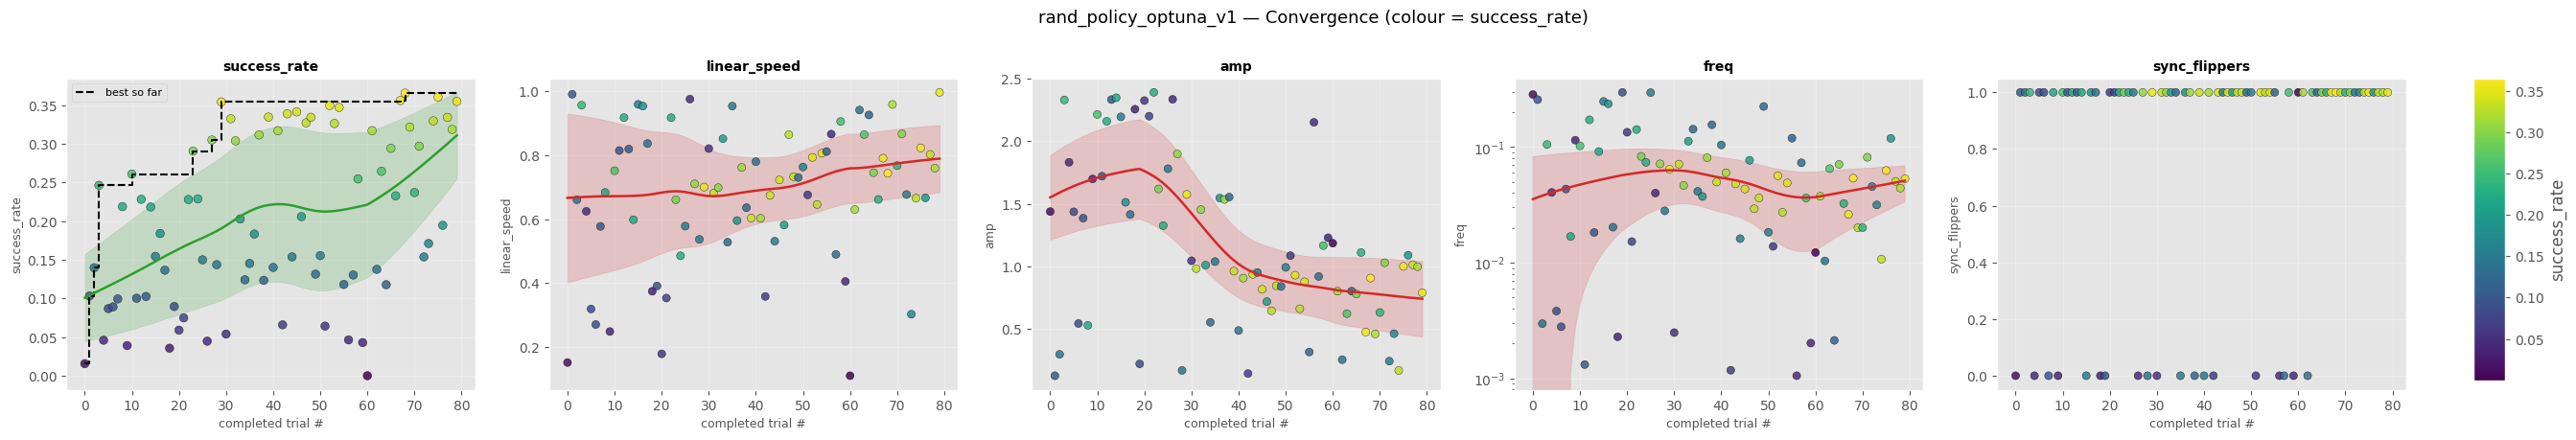

In [14]:
n_plots = 1 + len(PARAM_NAMES)
ncols   = min(n_plots, 5)
nrows   = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows))
axes = np.atleast_2d(axes)

run_order = np.arange(len(df), dtype=float)
sr_vals   = df[SR_COL].values
cmap      = plt.cm.viridis
norm      = plt.Normalize(sr_vals.min(), sr_vals.max())

def _envelope(ax, x, y, color="#d62728", frac=0.5):
    sm    = lowess(y, x, frac=frac, return_sorted=True)
    resid = y - np.interp(x, sm[:, 0], sm[:, 1])
    std_s = np.sqrt(np.maximum(lowess(resid**2, x, frac=frac, return_sorted=True)[:, 1], 0))
    ax.plot(sm[:, 0], sm[:, 1], "-", linewidth=1.8, color=color, zorder=5)
    ax.fill_between(sm[:, 0], sm[:, 1] - std_s, sm[:, 1] + std_s,
                    color=color, alpha=0.18, zorder=2)

# Panel 0: success_rate
ax0 = axes[0, 0]
ax0.scatter(run_order, sr_vals, c=sr_vals, cmap=cmap, norm=norm,
            s=40, edgecolors="black", linewidths=0.3, alpha=0.85, zorder=3)
if len(run_order) >= 8:
    _envelope(ax0, run_order, sr_vals, color="#2ca02c")
ax0.step(run_order, pd.Series(sr_vals).expanding().max().values,
         where="post", linewidth=1.5, color="black", linestyle="--",
         label="best so far", zorder=4)
ax0.set_xlabel("completed trial #", fontsize=9)
ax0.set_ylabel("success_rate", fontsize=9)
ax0.set_title("success_rate", fontsize=10, fontweight="bold")
ax0.legend(fontsize=8)
ax0.grid(True, alpha=0.3)

# Panels 1..N: parameters
for i, param in enumerate(PARAM_NAMES):
    ax = axes[(i + 1) // ncols, (i + 1) % ncols]
    y  = df[param].values
    ax.scatter(run_order, y, c=sr_vals, cmap=cmap, norm=norm,
               s=35, edgecolors="black", linewidths=0.3, alpha=0.85, zorder=3)
    if param not in CATEGORICAL and len(run_order) >= 8:
        _envelope(ax, run_order, y)
    if param in LOG_PARAMS:
        ax.set_yscale("log")
    ax.set_xlabel("completed trial #", fontsize=9)
    ax.set_ylabel(sname(param), fontsize=9)
    ax.set_title(sname(param), fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)

for idx in range(n_plots, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.012, 0.7])
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, label="success_rate")
fig.suptitle(f"{STUDY_NAME} — Convergence (colour = success_rate)", fontsize=13, y=1.01)
fig.tight_layout(rect=[0, 0, 0.92, 1.0])
plt.show()

## Optuna built-in visualizations

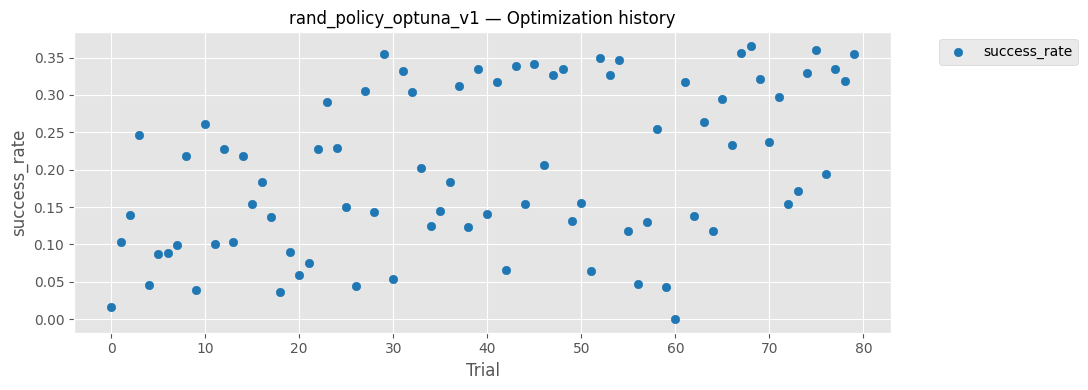

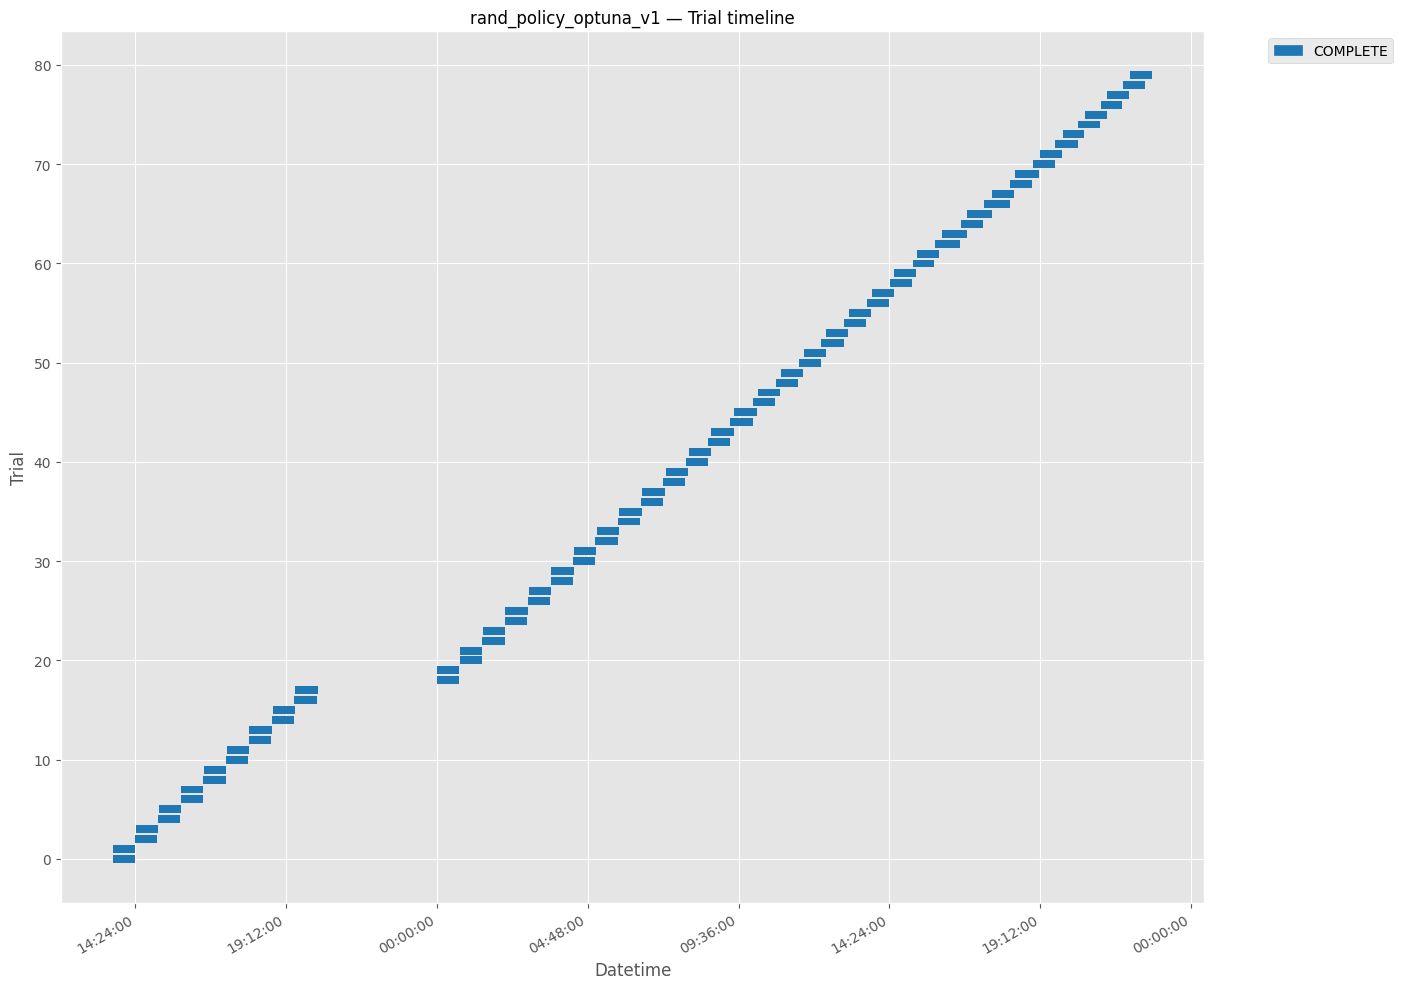

In [15]:
import optuna.visualization.matplotlib as ovm
import warnings
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

def _sr(t):
    return t.values[0] if t.values else t.user_attrs.get(SR_COL, float("nan"))

# Optimization history
ax = ovm.plot_optimization_history(study, target=_sr, target_name="success_rate")
ax.set_title(f"{STUDY_NAME} — Optimization history", fontsize=12)
ax.figure.set_size_inches(11, 4)
ax.figure.tight_layout()
plt.show()

# Trial timeline
ax = ovm.plot_timeline(study)
ax.set_title(f"{STUDY_NAME} — Trial timeline", fontsize=12)
ax.figure.set_size_inches(14, max(4, len(study.trials) // 8))
ax.figure.tight_layout()
plt.show()

## fANOVA parameter importance

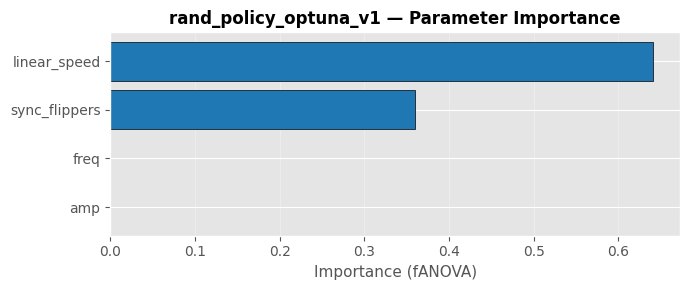


Importance ranking:
  linear_speed          0.6407
  sync_flippers         0.3593
  amp                   0.0000
  freq                  0.0000


In [16]:
try:
    all_param_names = list(trials[0].params.keys())
    importance = dict(optuna.importance.get_param_importances(study))
    # Pad params that fANOVA dropped (zero importance) so all 4 appear
    for p in all_param_names:
        importance.setdefault(p, 0.0)

    imp_df = pd.DataFrame({
        "parameter":  [sname(k) for k in importance],
        "importance": list(importance.values()),
    }).sort_values("importance")

    fig, ax = plt.subplots(figsize=(7, max(3, len(imp_df) * 0.5)))
    ax.barh(imp_df["parameter"], imp_df["importance"],
            color="#1f77b4", edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Importance (fANOVA)", fontsize=11)
    ax.set_title(f"{STUDY_NAME} — Parameter Importance", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")
    fig.tight_layout()
    plt.show()

    print("\nImportance ranking:")
    for _, row in imp_df.sort_values("importance", ascending=False).iterrows():
        print(f"  {row['parameter']:20s}  {row['importance']:.4f}")
except Exception as e:
    print(f"fANOVA unavailable: {e}")

## GP surrogate — 1-D marginal slices
Fits a GP on `success_rate` and sweeps each parameter while holding the others at the predicted optimum.

In [17]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from scipy.optimize import minimize

all_param_cols = CONTINUOUS + CATEGORICAL
X_raw = df[all_param_cols].values.astype(float)
y_gp  = df[SR_COL].values

log_mask = np.array([p in LOG_PARAMS for p in all_param_cols])
X_gp = X_raw.copy()
X_gp[:, log_mask] = np.log(np.clip(X_gp[:, log_mask], 1e-12, None))

X_min   = X_gp.min(axis=0)
X_max   = X_gp.max(axis=0)
X_range = np.where(X_max - X_min > 0, X_max - X_min, 1.0)
X_norm  = (X_gp - X_min) / X_range

kernel = ConstantKernel(1.0) * RBF(length_scale=np.ones(X_norm.shape[1])) + WhiteKernel(0.01)
gp     = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15,
                                   alpha=1e-6, normalize_y=True)
gp.fit(X_norm, y_gp)
print(f"GP fitted — log-marginal-likelihood: {gp.log_marginal_likelihood_value_:.2f}")

# Multi-start optimisation
rng = np.random.default_rng(42)
best_val, best_x_norm = -np.inf, None
for _ in range(300):
    x0  = rng.random(X_norm.shape[1])
    res = minimize(lambda x: -gp.predict(x.reshape(1, -1))[0],
                   x0, bounds=[(0, 1)] * X_norm.shape[1], method="L-BFGS-B")
    if -res.fun > best_val:
        best_val, best_x_norm = -res.fun, res.x.copy()

best_x_orig = best_x_norm * X_range + X_min
best_x_orig[log_mask] = np.exp(best_x_orig[log_mask])
for i, p in enumerate(all_param_cols):
    if p in CATEGORICAL:
        cats = sorted(df[p].unique())
        best_x_orig[i] = min(cats, key=lambda c: abs(c - best_x_orig[i]))

gp_mean, gp_std = gp.predict(best_x_norm.reshape(1, -1), return_std=True)
print(f"\nPredicted optimal success_rate : {gp_mean[0]:.4f} ± {gp_std[0]:.4f}")
print(f"Observed best success_rate     : {y_gp.max():.4f}")
print("\nPredicted optimal parameters:")
for i, p in enumerate(all_param_cols):
    print(f"  {sname(p):20s} = {best_x_orig[i]:.5g}")

GP fitted — log-marginal-likelihood: -57.61

Predicted optimal success_rate : 0.3588 ± 0.0291
Observed best success_rate     : 0.3654

Predicted optimal parameters:
  linear_speed         = 0.9457
  amp                  = 1.0311
  freq                 = 0.053048
  sync_flippers        = 1


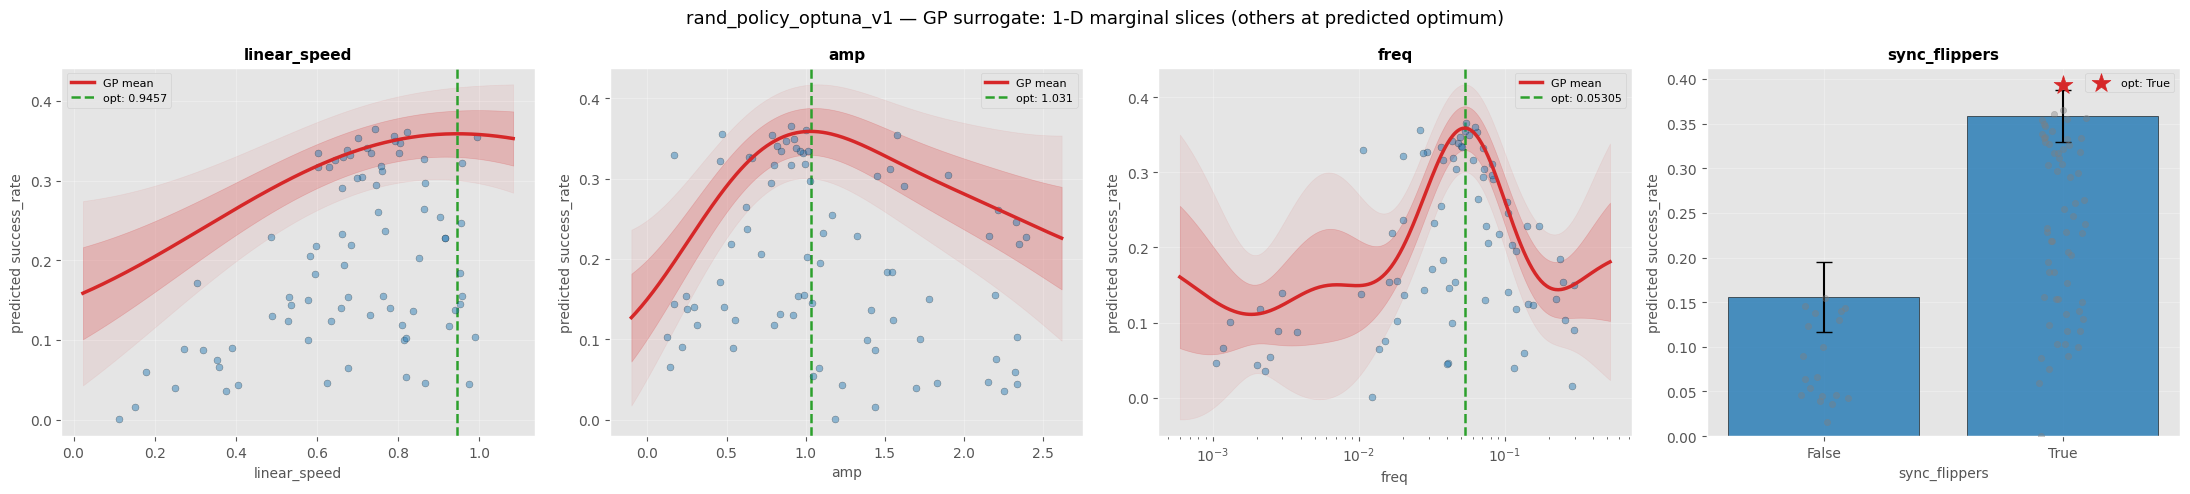

In [18]:
ncols = len(all_param_cols)
fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 5))
axes = np.atleast_1d(axes)

for idx, (ax, param) in enumerate(zip(axes, all_param_cols)):
    if param in CATEGORICAL:
        cats = sorted(df[param].unique())
        means, stds = [], []
        for cat in cats:
            x_test = best_x_norm.copy()
            x_test[idx] = (float(cat) - X_min[idx]) / X_range[idx]
            m, s = gp.predict(x_test.reshape(1, -1), return_std=True)
            means.append(m[0]); stds.append(s[0])
        means, stds = np.array(means), np.array(stds)
        ax.bar(range(len(cats)), means, yerr=stds, capsize=6,
               color="#1f77b4", edgecolor="black", alpha=0.8)
        ax.set_xticks(range(len(cats)))
        ax.set_xticklabels([str(c) for c in cats])
        ax.scatter(np.argmax(means), means.max() + stds[np.argmax(means)] + 0.005,
                   s=200, marker="*", color="#d62728", zorder=5,
                   label=f"opt: {cats[np.argmax(means)]}")
        obs_x = [list(cats).index(v) + rng.uniform(-0.1, 0.1)
                 for v in df[param].values]
        ax.scatter(obs_x, y_gp, s=20, alpha=0.4, color="gray", zorder=3)
        ax.legend(fontsize=8)
    else:
        col_vals = X_gp[:, idx]
        span     = col_vals.max() - col_vals.min()
        sweep    = np.linspace(col_vals.min() - 0.1*span, col_vals.max() + 0.1*span, 300)
        sw_norm  = (sweep - X_min[idx]) / X_range[idx]
        X_test   = np.tile(best_x_norm, (len(sweep), 1))
        X_test[:, idx] = sw_norm
        means, stds = gp.predict(X_test, return_std=True)
        sweep_plot = np.exp(sweep) if param in LOG_PARAMS else sweep
        ax.plot(sweep_plot, means, "-", linewidth=2.5, color="#d62728", zorder=5, label="GP mean")
        ax.fill_between(sweep_plot, means - stds,   means + stds,   color="#d62728", alpha=0.2)
        ax.fill_between(sweep_plot, means - 2*stds, means + 2*stds, color="#d62728", alpha=0.07)
        obs_x = np.exp(X_gp[:, idx]) if param in LOG_PARAMS else X_raw[:, idx]
        ax.scatter(obs_x, y_gp, s=25, alpha=0.45, color="#1f77b4",
                   edgecolors="black", linewidths=0.3, zorder=3)
        ax.axvline(best_x_orig[idx], color="#2ca02c", linestyle="--", linewidth=1.8,
                   label=f"opt: {best_x_orig[idx]:.4g}")
        if param in LOG_PARAMS:
            ax.set_xscale("log")
        ax.legend(fontsize=8)

    ax.set_xlabel(sname(param), fontsize=10)
    ax.set_ylabel("predicted success_rate", fontsize=10)
    ax.set_title(sname(param), fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

fig.suptitle(f"{STUDY_NAME} — GP surrogate: 1-D marginal slices (others at predicted optimum)",
             fontsize=13)
fig.tight_layout()
plt.show()